In [1]:
!pip install torch torchvision timm matplotlib scikit-learn tqdm

In [2]:
import os
import zipfile

# Download dataset.zip directly from your computer to the Colab VM
!wget -O dataset.zip https://2aaefedc12b734.lhr.life/dataset.zip

# Unzip it
print("Extracting dataset.zip...")
with zipfile.ZipFile('dataset.zip', 'r') as z:
    z.extractall('.')
print("Extraction complete!")

print(f"Working directory: {os.getcwd()}")
print("Files:", os.listdir('.'))


--2026-04-17 06:29:16--  https://2aaefedc12b734.lhr.life/dataset.zip
Resolving 2aaefedc12b734.lhr.life (2aaefedc12b734.lhr.life)... 3.208.46.244, 3.234.18.192, 54.172.225.3
Connecting to 2aaefedc12b734.lhr.life (2aaefedc12b734.lhr.life)|3.208.46.244|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 56953044 (54M) [application/x-zip-compressed]
Saving to: ‘dataset.zip’

dataset.zip         100%[===================>]  54.31M   526KB/s    in 1m 47s  

2026-04-17 06:31:03 (521 KB/s) - ‘dataset.zip’ saved [56953044/56953044]

Extracting dataset.zip...
Extraction complete!
Working directory: /content
Files: ['.config', 'dataset\\train\\train\\forest_needleleaf\\sun_acldfctnbrisxzjh.jpg', 'dataset\\train\\train\\forest_broadleaf\\sun_agxabiochdwjboza.jpg', 'dataset\\test\\test\\street\\sun_acildorqqtcqspcp.jpg', 'dataset\\test\\test\\office\\sun_ajynyztbkborgzyi.jpg', 'dataset\\test\\test\\street\\sun_ahgcphrstrpgrnwv.jpg', 'dataset\\train\\train\\beach\\sun_acwjzarrcm

In [3]:
# Check if the data folder exists and list its contents
import os

print("Checking for archive/train/train in:", os.getcwd())
if os.path.exists("archive/train/train"):
    print("Found archive/train/train!")
    print("Sample folders:", os.listdir("archive/train/train")[:10])
else:
    print("archive/train/train NOT FOUND!")
    # List everything in the current directory for debugging
    print("Current directory contents:", os.listdir())

Checking for archive/train/train in: /content
archive/train/train NOT FOUND!
Current directory contents: ['.config', 'dataset\\train\\train\\forest_needleleaf\\sun_acldfctnbrisxzjh.jpg', 'dataset\\train\\train\\forest_broadleaf\\sun_agxabiochdwjboza.jpg', 'dataset\\test\\test\\street\\sun_acildorqqtcqspcp.jpg', 'dataset\\test\\test\\office\\sun_ajynyztbkborgzyi.jpg', 'dataset\\test\\test\\street\\sun_ahgcphrstrpgrnwv.jpg', 'dataset\\train\\train\\beach\\sun_acwjzarrcmoygwde.jpg', 'dataset\\test\\test\\street\\sun_agtpyiscmdidhpgk.jpg', 'dataset\\test\\test\\street\\sun_adhrqoimlpnhwwqr.jpg', 'dataset\\train\\train\\office\\sun_awzxndenprgrlztp.jpg', 'dataset\\test\\test\\beach\\sun_abvhktubnfutdzyp.jpg', 'dataset\\train\\train\\forest_broadleaf\\sun_aofddvhkjfdagokt.jpg', 'dataset\\train\\train\\office\\sun_akllrztlqynjhjms.jpg', 'dataset\\train\\train\\forest_broadleaf\\sun_aijnekdvgdkmumhb.jpg', 'dataset\\test\\test\\forest_needleleaf\\sun_ajgxbesgeiwalpxd.jpg', 'dataset\\train\\trai

In [5]:
# Extract using Linux unzip which handles Windows paths properly
!unzip -q dataset.zip

import os
# Verify it worked!
print(os.listdir('dataset/train/train')[:5])


['forest_broadleaf', 'forest_needleleaf', 'street', 'office', 'beach']


In [6]:
import os
import shutil

source_train = "dataset/train/train"
source_test = "dataset/test/test"

target_base = "dataset_4class"
target_train = os.path.join(target_base, "train")
target_test = os.path.join(target_base, "test")

classes_needed = ["beach", "forest_broadleaf", "office", "street"]

# Create folders
for split in ["train", "test"]:
    for cls in classes_needed:
        os.makedirs(os.path.join(target_base, split, cls), exist_ok=True)

# Copy training data
for cls in classes_needed:
    shutil.copytree(
        os.path.join(source_train, cls),
        os.path.join(target_train, cls),
        dirs_exist_ok=True
    )

# Copy testing data
for cls in classes_needed:
    shutil.copytree(
        os.path.join(source_test, cls),
        os.path.join(target_test, cls),
        dirs_exist_ok=True
    )

print("4-class dataset created successfully!")

4-class dataset created successfully!


In [7]:
os.rename("dataset_4class/train/forest_broadleaf",
          "dataset_4class/train/forest")

os.rename("dataset_4class/test/forest_broadleaf",
          "dataset_4class/test/forest")

In [8]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# ImageNet normalization (important for pretrained models)
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

# transform = transforms.Compose([
#     transforms.Resize((224,224)),
#     transforms.RandomHorizontalFlip(),
#     transforms.ToTensor(),
# ])

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])

train_dataset = datasets.ImageFolder("dataset_4class/train", transform=train_transform)
test_dataset = datasets.ImageFolder("dataset_4class/test", transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

print(train_dataset.classes)
class_names = train_dataset.classes
num_classes = len(class_names)

print(f"Classes: {class_names}")
print(f"Number of classes: {num_classes}")
print(f"Training samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


['beach', 'forest', 'office', 'street']
Classes: ['beach', 'forest', 'office', 'street']
Number of classes: 4
Training samples: 216
Test samples: 184
Using device: cuda


In [9]:
import torch
from tqdm import tqdm
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import matplotlib.pyplot as plt

def train_model(model, train_loader, criterion, optimizer, device, num_epochs=5, model_name="Model"):
    """Train a model and return training history."""
    history = {"train_loss": [], "val_acc": []}

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        # Evaluate after each epoch
        val_acc = evaluate_model(model, test_loader, device)
        history["train_loss"].append(running_loss)
        history["val_acc"].append(val_acc)

        print(f"[{model_name}] Epoch {epoch+1}/{num_epochs} — Loss: {running_loss:.4f}, Val Acc: {val_acc:.2f}%")

    return history


def evaluate_model(model, loader, device):
    """Evaluate model accuracy."""
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return 100 * correct / total


def get_predictions(model, loader, device):
    """Get all predictions and true labels."""
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    return np.array(all_preds), np.array(all_labels)


def plot_confusion_matrix(model, loader, device, class_names, model_name):
    """Plot confusion matrix for a model."""
    preds, labels = get_predictions(model, loader, device)
    cm = confusion_matrix(labels, preds)

    plt.figure(figsize=(6, 5))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title(f"Confusion Matrix — {model_name}")
    plt.colorbar()
    tick_marks = np.arange(len(class_names))
    plt.xticks(tick_marks, class_names, rotation=45, ha='right')
    plt.yticks(tick_marks, class_names)

    # Add text annotations
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, str(cm[i, j]),
                     ha='center', va='center',
                     color='white' if cm[i, j] > cm.max() / 2 else 'black')

    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

    # Print classification report
    print(f"\n📊 Classification Report — {model_name}")
    print(classification_report(labels, preds, target_names=class_names))

    return preds, labels

In [10]:
from torchvision.models import resnet50, ResNet50_Weights

# Build model
resnet_model = resnet50(weights=ResNet50_Weights.DEFAULT)
resnet_model.fc = nn.Linear(resnet_model.fc.in_features, num_classes)
resnet_model = resnet_model.to(device)

# Optimizer & Loss
resnet_criterion = nn.CrossEntropyLoss()
resnet_optimizer = torch.optim.Adam(resnet_model.parameters(), lr=0.0001)

# Train
print("=" * 60)
print("🔵 Training ResNet50")
print("=" * 60)
resnet_history = train_model(
    resnet_model, train_loader, resnet_criterion, resnet_optimizer,
    device, num_epochs=5, model_name="ResNet50"
)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 185MB/s]


🔵 Training ResNet50
[ResNet50] Epoch 1/5 — Loss: 8.8128, Val Acc: 92.39%
[ResNet50] Epoch 2/5 — Loss: 5.8829, Val Acc: 97.83%
[ResNet50] Epoch 3/5 — Loss: 2.9948, Val Acc: 98.91%
[ResNet50] Epoch 4/5 — Loss: 1.1120, Val Acc: 99.46%
[ResNet50] Epoch 5/5 — Loss: 0.4094, Val Acc: 99.46%


🔵 Evaluating ResNet50

✅ ResNet50 Final Test Accuracy: 99.46%



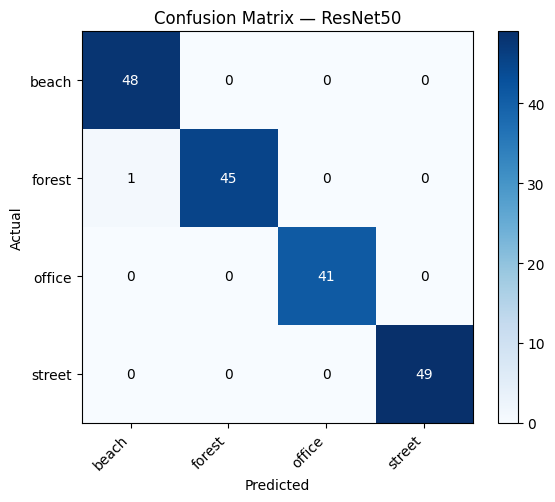


📊 Classification Report — ResNet50
              precision    recall  f1-score   support

       beach       0.98      1.00      0.99        48
      forest       1.00      0.98      0.99        46
      office       1.00      1.00      1.00        41
      street       1.00      1.00      1.00        49

    accuracy                           0.99       184
   macro avg       0.99      0.99      0.99       184
weighted avg       0.99      0.99      0.99       184

💾 Saved: resnet50_scene_model.pth


In [11]:
print("=" * 60)
print("🔵 Evaluating ResNet50")
print("=" * 60)
resnet_acc = evaluate_model(resnet_model, test_loader, device)
print(f"\n✅ ResNet50 Final Test Accuracy: {resnet_acc:.2f}%\n")
plot_confusion_matrix(resnet_model, test_loader, device, class_names, "ResNet50")

# Save model
torch.save(resnet_model.state_dict(), "resnet50_scene_model.pth")
print("💾 Saved: resnet50_scene_model.pth")


# ## Model 2: EfficientNet-B0

In [12]:
import timm

# Build model
effnet_model = timm.create_model('efficientnet_b0', pretrained=True, num_classes=num_classes)
effnet_model = effnet_model.to(device)

# Optimizer & Loss
effnet_criterion = nn.CrossEntropyLoss()
effnet_optimizer = torch.optim.Adam(effnet_model.parameters(), lr=0.0001)

# Train
print("=" * 60)
print("🟢 Training EfficientNet-B0")
print("=" * 60)
effnet_history = train_model(
    effnet_model, train_loader, effnet_criterion, effnet_optimizer,
    device, num_epochs=5, model_name="EfficientNet-B0"
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:103: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

🟢 Training EfficientNet-B0
[EfficientNet-B0] Epoch 1/5 — Loss: 21.0079, Val Acc: 55.98%
[EfficientNet-B0] Epoch 2/5 — Loss: 3.8074, Val Acc: 86.41%
[EfficientNet-B0] Epoch 3/5 — Loss: 0.5459, Val Acc: 92.39%
[EfficientNet-B0] Epoch 4/5 — Loss: 0.2921, Val Acc: 95.11%
[EfficientNet-B0] Epoch 5/5 — Loss: 0.0550, Val Acc: 95.65%


🟢 Evaluating EfficientNet-B0

✅ EfficientNet-B0 Final Test Accuracy: 95.65%



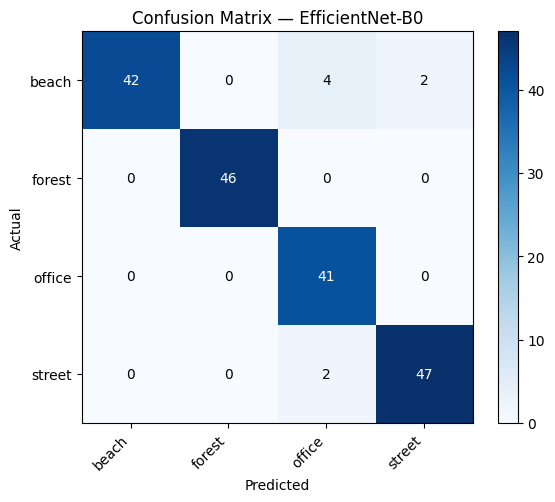


📊 Classification Report — EfficientNet-B0
              precision    recall  f1-score   support

       beach       1.00      0.88      0.93        48
      forest       1.00      1.00      1.00        46
      office       0.87      1.00      0.93        41
      street       0.96      0.96      0.96        49

    accuracy                           0.96       184
   macro avg       0.96      0.96      0.96       184
weighted avg       0.96      0.96      0.96       184

💾 Saved: efficientnet_b0_scene_model.pth


In [13]:
print("=" * 60)
print("🟢 Evaluating EfficientNet-B0")
print("=" * 60)
effnet_acc = evaluate_model(effnet_model, test_loader, device)
print(f"\n✅ EfficientNet-B0 Final Test Accuracy: {effnet_acc:.2f}%\n")
plot_confusion_matrix(effnet_model, test_loader, device, class_names, "EfficientNet-B0")

# Save model
torch.save(effnet_model.state_dict(), "efficientnet_b0_scene_model.pth")
print("💾 Saved: efficientnet_b0_scene_model.pth")

# ## Model 3: ViT (Vision Transformer)

In [14]:
import timm

# Build model
vit_model = timm.create_model('vit_base_patch16_224', pretrained=True, num_classes=num_classes)
vit_model = vit_model.to(device)

# Optimizer & Loss
vit_criterion = nn.CrossEntropyLoss()
vit_optimizer = torch.optim.Adam(vit_model.parameters(), lr=0.0001)

# Train
print("=" * 60)
print("🟣 Training ViT-Base-Patch16-224")
print("=" * 60)
vit_history = train_model(
    vit_model, train_loader, vit_criterion, vit_optimizer,
    device, num_epochs=5, model_name="ViT-Base"
)

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

🟣 Training ViT-Base-Patch16-224
[ViT-Base] Epoch 1/5 — Loss: 3.8349, Val Acc: 100.00%
[ViT-Base] Epoch 2/5 — Loss: 0.1599, Val Acc: 96.74%
[ViT-Base] Epoch 3/5 — Loss: 0.2828, Val Acc: 98.37%
[ViT-Base] Epoch 4/5 — Loss: 0.1709, Val Acc: 99.46%
[ViT-Base] Epoch 5/5 — Loss: 0.4223, Val Acc: 98.91%


🟣 Evaluating ViT-Base-Patch16-224

✅ ViT-Base Final Test Accuracy: 98.91%



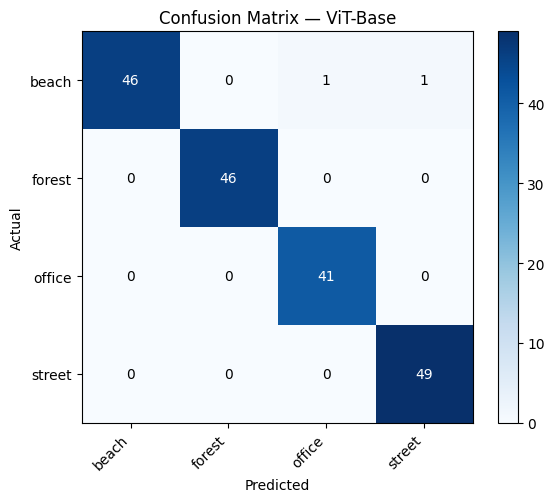


📊 Classification Report — ViT-Base
              precision    recall  f1-score   support

       beach       1.00      0.96      0.98        48
      forest       1.00      1.00      1.00        46
      office       0.98      1.00      0.99        41
      street       0.98      1.00      0.99        49

    accuracy                           0.99       184
   macro avg       0.99      0.99      0.99       184
weighted avg       0.99      0.99      0.99       184

💾 Saved: vit_base_scene_model.pth


In [15]:
print("=" * 60)
print("🟣 Evaluating ViT-Base-Patch16-224")
print("=" * 60)
vit_acc = evaluate_model(vit_model, test_loader, device)
print(f"\n✅ ViT-Base Final Test Accuracy: {vit_acc:.2f}%\n")
plot_confusion_matrix(vit_model, test_loader, device, class_names, "ViT-Base")

# Save model
torch.save(vit_model.state_dict(), "vit_base_scene_model.pth")
print("💾 Saved: vit_base_scene_model.pth")

## Model Comparison

In [16]:
print("=" * 60)
print("📊 MODEL COMPARISON — Scene Classification (4 Classes)")
print("=" * 60)
print(f"{'Model':<25} {'Test Accuracy':>15}")
print("-" * 42)
print(f"{'ResNet50':<25} {resnet_acc:>14.2f}%")
print(f"{'EfficientNet-B0':<25} {effnet_acc:>14.2f}%")
print(f"{'ViT-Base-Patch16-224':<25} {vit_acc:>14.2f}%")
print("-" * 42)

# Find best model
best_name = ["ResNet50", "EfficientNet-B0", "ViT-Base"][
    [resnet_acc, effnet_acc, vit_acc].index(max(resnet_acc, effnet_acc, vit_acc))
]
print(f"\n🏆 Best Model: {best_name} ({max(resnet_acc, effnet_acc, vit_acc):.2f}%)")

📊 MODEL COMPARISON — Scene Classification (4 Classes)
Model                       Test Accuracy
------------------------------------------
ResNet50                           99.46%
EfficientNet-B0                    95.65%
ViT-Base-Patch16-224               98.91%
------------------------------------------

🏆 Best Model: ResNet50 (99.46%)


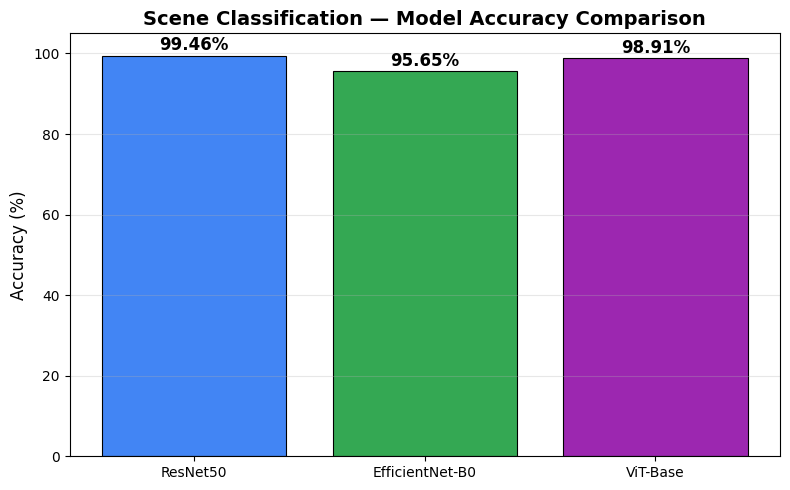

In [17]:
import matplotlib.pyplot as plt

model_names = ["ResNet50", "EfficientNet-B0", "ViT-Base"]
accuracies = [resnet_acc, effnet_acc, vit_acc]
colors = ['#4285F4', '#34A853', '#9C27B0']

plt.figure(figsize=(8, 5))
bars = plt.bar(model_names, accuracies, color=colors, edgecolor='black', linewidth=0.8)

# Add value labels on bars
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
             f'{acc:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=12)

plt.title("Scene Classification — Model Accuracy Comparison", fontsize=14, fontweight='bold')
plt.ylabel("Accuracy (%)", fontsize=12)
plt.ylim(0, 105)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

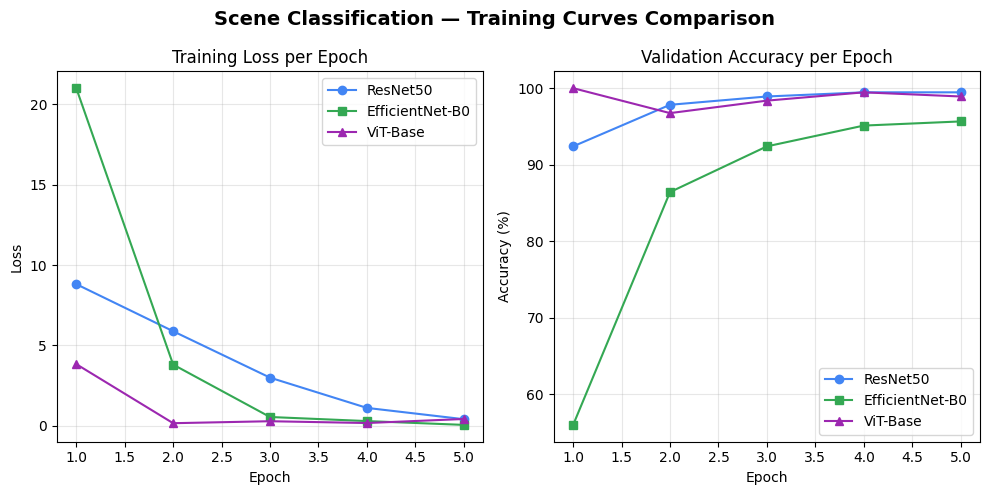

In [18]:
import matplotlib.pyplot as plt

epochs_range = range(1, 6)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, resnet_history["train_loss"], 'o-', label="ResNet50", color='#4285F4')
plt.plot(epochs_range, effnet_history["train_loss"], 's-', label="EfficientNet-B0", color='#34A853')
plt.plot(epochs_range, vit_history["train_loss"], '^-', label="ViT-Base", color='#9C27B0')
plt.title("Training Loss per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, resnet_history["val_acc"], 'o-', label="ResNet50", color='#4285F4')
plt.plot(epochs_range, effnet_history["val_acc"], 's-', label="EfficientNet-B0", color='#34A853')
plt.plot(epochs_range, vit_history["val_acc"], '^-', label="ViT-Base", color='#9C27B0')
plt.title("Validation Accuracy per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.grid(alpha=0.3)

plt.suptitle("Scene Classification — Training Curves Comparison", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Summary
 - **ResNet50**: Classic CNN architecture, fast training, strong baseline
 - **EfficientNet-B0**: Efficient scaling, good accuracy with fewer parameters
 - **ViT-Base**: Transformer-based, captures global context, may need more data to shine

 All models were fine-tuned from ImageNet pretrained weights on a 4-class subset

In [ ]:
from google.colab import files

# Download all trained models
files.download('resnet50_scene_model.pth')
files.download('efficientnet_b0_scene_model.pth')
files.download('vit_base_scene_model.pth')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [20]:
import subprocess
import json

for model_file in ['resnet50_scene_model.pth', 'efficientnet_b0_scene_model.pth', 'vit_base_scene_model.pth']:
    result = subprocess.run(['curl', '-F', f'file=@{model_file}', 'https://file.io'], capture_output=True, text=True)
    data = json.loads(result.stdout)
    print(f"📥 {model_file}: {data.get('link', 'Upload failed')}")


JSONDecodeError: Expecting value: line 1 column 1 (char 0)

In [24]:
import subprocess, json

model_files = ['resnet50_scene_model.pth', 'efficientnet_b0_scene_model.pth', 'vit_base_scene_model.pth']

for model_file in model_files:
    print(f"⬆️ Uploading {model_file}...")
    result = subprocess.run(
        ['curl', '-F', f'file=@{model_file}', 'https://tmpfiles.org/api/v1/upload'],
        capture_output=True, text=True, timeout=600
    )
    try:
        data = json.loads(result.stdout)
        url = data['data']['url'].replace('tmpfiles.org/', 'tmpfiles.org/dl/')
        print(f"✅ Download: {url}")
    except:
        print(f"Output: {result.stdout[:300]}")
        print(f"Error: {result.stderr[:200]}")
    print()


⬆️ Uploading resnet50_scene_model.pth...
✅ Download: http://tmpfiles.org/dl/34044545/resnet50_scene_model.pth

⬆️ Uploading efficientnet_b0_scene_model.pth...
✅ Download: http://tmpfiles.org/dl/34044551/efficientnet_b0_scene_model.pth

⬆️ Uploading vit_base_scene_model.pth...
Output: <html>
<head><title>413 Payload Too Large</title></head>
<body>
<center><h1>413 Payload Too Large</h1></center>
<hr><center>cloudflare</center>
</body>
</html>

Error:   % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed

  0     0    0     0    0     0      0   



In [ ]:
# from torchvision.models import resnet50, ResNet50_Weights
# import torchvision.models as models
# import torch.nn as nn
# import torch

# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# model = resnet50(weights=ResNet50_Weights.DEFAULT)
# model.fc = nn.Linear(model.fc.in_features, 4)
# model = model.to(device)

# criterion = nn.CrossEntropyLoss()
# optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 199MB/s]


In [ ]:
# def evaluate(model, loader):
#     model.eval()
#     correct = 0
#     total = 0
    
#     with torch.no_grad():
#         for images, labels in loader:
#             images, labels = images.to(device), labels.to(device)
#             outputs = model(images)
#             _, predicted = torch.max(outputs, 1)
            
#             total += labels.size(0)
#             correct += (predicted == labels).sum().item()
    
#     return 100 * correct / total

In [ ]:
# for epoch in range(5):
#     model.train()
#     running_loss = 0
    
#     for images, labels in train_loader:
#         images, labels = images.to(device), labels.to(device)
        
#         optimizer.zero_grad()
#         outputs = model(images)
#         loss = criterion(outputs, labels)
#         loss.backward()
#         optimizer.step()
        
#         running_loss += loss.item()
    
#     val_acc = evaluate(model, test_loader)
    
#     print(f"Epoch {epoch+1}")
#     print(f"Training Loss: {running_loss:.4f}")
#     print(f"Validation Accuracy: {val_acc:.2f}%")
#     print("---------------")

Epoch 1
Training Loss: 8.6333
Validation Accuracy: 94.57%
---------------
Epoch 2
Training Loss: 4.7869
Validation Accuracy: 97.83%
---------------
Epoch 3
Training Loss: 2.2305
Validation Accuracy: 98.91%
---------------
Epoch 4
Training Loss: 0.8639
Validation Accuracy: 99.46%
---------------
Epoch 5
Training Loss: 0.3878
Validation Accuracy: 99.46%
---------------


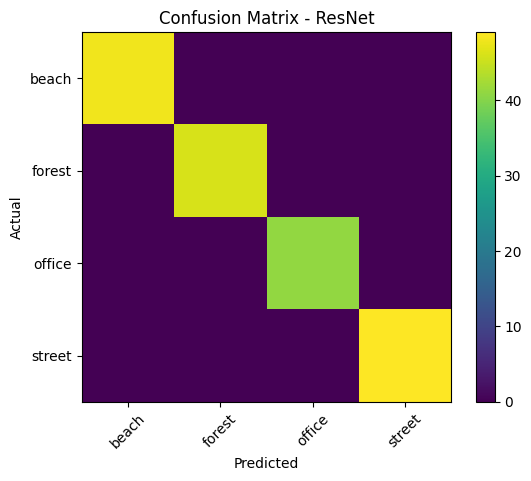

In [ ]:
# from sklearn.metrics import confusion_matrix
# import numpy as np
# import matplotlib.pyplot as plt

# model.eval()
# all_preds = []
# all_labels = []

# with torch.no_grad():
#     for images, labels in test_loader:
#         images = images.to(device)
#         outputs = model(images)
#         _, preds = torch.max(outputs, 1)
        
#         all_preds.extend(preds.cpu().numpy())
#         all_labels.extend(labels.numpy())

# cm = confusion_matrix(all_labels, all_preds)

# plt.imshow(cm)
# plt.title("Confusion Matrix - ResNet")
# plt.colorbar()
# plt.xticks(np.arange(4), train_dataset.classes, rotation=45)
# plt.yticks(np.arange(4), train_dataset.classes)
# plt.xlabel("Predicted")
# plt.ylabel("Actual")
# plt.show()

In [ ]:
# torch.save(model.state_dict(), "resnet_scene_model.pth")

In [ ]:
# for epoch in range(3):
#     model.train()
#     running_loss = 0
    
#     for images, labels in train_loader:
#         images, labels = images.to(device), labels.to(device)
        
#         optimizer.zero_grad()
#         outputs = model(images)
#         loss = criterion(outputs, labels)
#         loss.backward()
#         optimizer.step()
        
#         running_loss += loss.item()
    
#     print(f"Epoch {epoch+1}, Loss: {running_loss:.4f}")

Epoch 1, Loss: 5.2670
Epoch 2, Loss: 0.5119
Epoch 3, Loss: 0.0949
